In [20]:
# This is how you calculate eigen stuff in Numpy:
import numpy as np

# Define a 3x3 square matrix
A = np.array([[0.5, 0.5, 0.25],
              [0.25, 0, 0.25],
              [0.25, 0.5, 0.5]])

# Compute eigenvalues and right eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues:
 [ 1.    0.25 -0.25]
Eigenvectors:
 [[-6.66666667e-01 -7.07106781e-01  4.08248290e-01]
 [-3.33333333e-01 -1.01150648e-16 -8.16496581e-01]
 [-6.66666667e-01  7.07106781e-01  4.08248290e-01]]


In [ ]:
# TODO: now modify the code and check the eigen stuff of your A matrix from Task #2

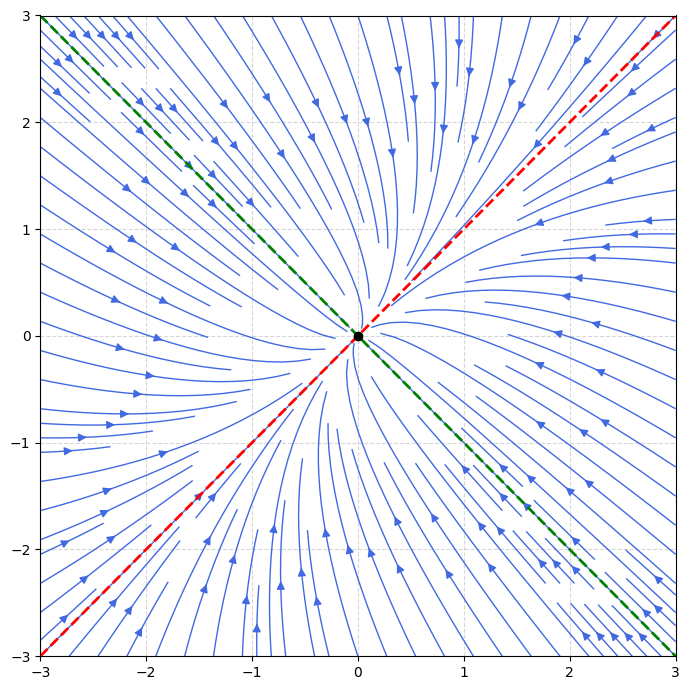

In [16]:
# This is how you plot a phase diagram, a stable drain in this case:

import numpy as np
import matplotlib.pyplot as plt

# Grid definition
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)

# System equations: dx/dt = -3x + y, dy/dt = x - 3y
U = -3 * X + Y
V = X - 3 * Y

fig, ax = plt.subplots(figsize=(7, 7))
ax.streamplot(X, Y, U, V, color='royalblue', density=1.5, arrowsize=1.2, linewidth=1)

# Invariant lines (eigenspaces)
t_vals = np.linspace(-3, 3, 100)
ax.plot(t_vals, t_vals, 'r--', linewidth=2, label=r'Slow Eigenspace $\lambda_1 = 2$ ')
ax.plot(t_vals, -t_vals, 'g--', linewidth=2, label=r'Fast Eigenspace $\lambda_2 = 4$ ')
ax.plot(0, 0, 'ko', markersize=6, label='Fixed point (0, 0)')

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
plt.tight_layout()
plt.show()

In [ ]:
# TODO: Now modify the codes and graph the phase protrait in task#2

In [17]:
# Now this is how you do DH parameters in Numpy:
import numpy as np
# run this first
A = np.array ([[1,0,2],
               [0,1,0],
               [0,0,1]     # this row will always be 0, 0, 1 for DH parameters
               ])

# this is the tranlation matrix in DH paramter form.

# For the first arm, arm length (L1) = 2
a = np.array ([[0],
               [1],
               [1]])

# this is the starting position (0,1, z=1).
# We need this z=1 in the vector space (and matrix) so our math could work.

A @ a

# after this opeartion, we should step forward in the L1-direction for 2.

B = np.array ([[1,0,0],
               [0,1,4],
               [0,0,1]
               ])
# this is the tranlation matrix for the second arm, L2 = 4

B@A@a

# with this opereration, we stepped 2 in the L1 direction and 4 in the L2 direction.
# [new posiiton]=[B][A][old position]

array([[2],
       [5],
       [1]])

In [18]:
#       If we rotate pi/4 degree                             This is the form of:
A_rot = np.array ([[np.cos(np.pi/4), -np.sin(np.pi/4),  0], # ([[cos(),-sin(), 0],
                   [np.sin(np.pi/4),  np.cos(np.pi/4),  0], #.  [sin(),cos(),  0],
                   [0,                    0,        1]      #   [0,     0,     1]
                  ])                                        # written in numpy

In [19]:
new_A = A @ A_rot @ a
print ('First rotation then translation will get:')
print (new_A)
print ()

new_A_2 = A_rot @ A @ a
print ('First translation then rotatoin will get:')
print (new_A_2)

# new_A position will be different from new_A_2 position!

First rotation then translation will get:
[[1.29289322]
 [0.70710678]
 [1.        ]]

First translation then rotatoin will get:
[[0.70710678]
 [2.12132034]
 [1.        ]]


So for the full arm, we are going to need:


$$
[New position] =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & L2 \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos\theta_2 & -\sin\theta_2 & 0 \\
\sin\theta_2 & \cos\theta_2 & 0 \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 & L1 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos\theta_1 & -\sin\theta_1 & 0 \\
\sin\theta_1 & \cos\theta_1 & 0 \\
0 & 0 & 1
\end{bmatrix}
[Old position]
$$

where four matrix multiply into each other sequentially.


In [ ]:
#TODO: Validate your DH parameter matrix here and check if that matches your analytical result.